# ANNNI model

We consider the one-dimensional axial next-nearest-neighbor Ising (ANNNI) model
$$
H
=\frac{J_1}{4} \sum_{i} Z_i Z_{i+1}
+\frac{J_2}{4} \sum_{i} Z_i Z_{i+2}
-\frac{G}{2} \sum_{i} X_i\,.
$$

### Parameter setting:

- **Task:** Ground state preparation
- **Figure:** Energy dynamics
- **System size:** $L=4$ sites
- **Inverse temperature:**  $\beta=1$
- **Gaussian filter width:** $\sigma=2$
- **Coupling strengths:** $\Gamma/\sigma \in \{1, 0.5, 0.25, 0.1, 0.05, 0.01\}$
- **Bath frequency sampling:** $\omega$ is uniformly sampled from [0,5]
- **System operator sampling:** spin operators

In [7]:
import quimb as qu
import numpy as np
import random
from numpy import linalg as LA
from scipy.linalg import expm
from scipy.sparse.linalg import expm as sparse_expm
from operator import add
from autoray import do, dag
from scipy.sparse import coo_matrix, bmat, csr_matrix
from scipy.integrate import odeint, complex_ode
import matplotlib as mpl # noqa
import matplotlib.pyplot as plt # noqa
from tqdm import tqdm
from quimb.tensor.tensor_1d_compress import *

from hamiltonians import h_annni,jw_spin_ops
from channels import _expm_from_eigh,_sym_herm,f_gaussian

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning

op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

In [ ]:
# --- fix all random seeds for reproducibility ---
np.random.seed(50)
random.seed(50)

N=4 #number of sites in the physical model
sigma = 4 #width of the Gaussian pulse
Ss = 5 * sigma #simulation time in one iteration
dTime = 0.1 #time step size in one iteration
Nstep = 2000 #number of iterations
dims = [2] * (N+1) #total system+bath dimension
BB = 5 #maximum bath frequency
alpha_list = np.array([1, 0.5, 0.25, 0.1, 0.05, 0.01]) * (sigma**0.5) #different choice of alpha

#ANNNI model Hamiltonian
Hamsys = h_annni(L=N, J1=-0.5, J2=-0.15, g=0.1, h=0.0, cyclic=True)
Hamsys = Hamsys.toarray()
eigenvalues, eigenvectors = LA.eig(Hamsys)
eigenvalues = np.real_if_close(eigenvalues, tol=1e-12)  # drop tiny imaginary parts
# Sort by real part
idx = np.argsort(np.real(eigenvalues))
ground_energy = np.real(eigenvalues[idx[0]])
ground_vector_1 = eigenvectors[:, idx[0]]
ground_vector_2 = eigenvectors[:, idx[1]]
rhoground = np.outer(ground_vector_1, ground_vector_1.conj())+np.outer(ground_vector_2, ground_vector_2.conj())
rhoground = rhoground/rhoground.trace()
Hamsys_original = Hamsys.copy()
Hamsys = qu.kron(Hamsys, qu.eye(2))
jump_op_array = jw_spin_ops(N) #sample from spin operators


#Initial state 
rhosys = np.zeros((2**N, 2**N), dtype=complex)
rhosys[0,0] = 1.0

#simulation loop
fidelity = np.zeros((Nstep+1,len(alpha_list)))
energy = np.zeros((Nstep+1,len(alpha_list)))
for idx in range(len(alpha_list)):
    fidelity[0,idx] = np.real(ground_vector_1.conj().T @ rhosys @ ground_vector_1+ground_vector_2.conj().T @ rhosys @ ground_vector_2)
energy[0,:] = np.real(np.trace(Hamsys_original @ rhosys))
rhosys_list = [rhosys.copy() for _ in range(len(alpha_list))]

for i in tqdm(range(Nstep)):

    omega = random.uniform(0, BB)
    Hambath = -omega * qu.spin_operator('z', **op_kws)
    Hambath = Hambath.toarray()
    rhobath = np.eye(2)
    rhobath[1,1] = 0
    Hambath = qu.kron(qu.eye(2**(N), **op_kws), Hambath)
    Hambath = Hambath.toarray()

    k = random.randint(0, N-1)
    # for spin model
    A = random.choice(jump_op_array)
    B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)
    sign_random = (-1)**(random.randint(0,1))
    interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
    interact += interact.conj().T

    for idx, alpha in enumerate(alpha_list):

        U = np.eye(2**(N+1))

        rho = np.kron(rhosys_list[idx], rhobath)

        # build H0 
        H0 = _sym_herm(Hamsys + Hambath)

        # eigendecomp of H0 once → U0_half = exp(-i H0 dt / 2)
        w0, Q0   = np.linalg.eigh(H0)
        U0_half  = _expm_from_eigh(Q0, w0, factor=(-1j * dTime / 2.0))

        # build interaction V
        V   = _sym_herm(interact)

        # eigendecomp of V once → later we reuse to get Uv(amp) fast
        wv, Qv = np.linalg.eigh(V.toarray())

        # precompute the pulse values for this i
        nsub  = 2*round(Ss/dTime) + 1
        tgrid = (np.arange(nsub) * dTime) - Ss
        fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

        for k in range(nsub):
            amp = fvals[k] * alpha
            Uv = _expm_from_eigh(Qv, wv, factor=(-1j * amp * dTime))
            dU = U0_half @ Uv @ U0_half

            U = U @ dU

        rho = U  @ rho  @ U.conj().T
        rhosys_list[idx] = qu.ptr(rho, dims, list(range(N)))
        fidelity[i+1,idx] = np.real(ground_vector_1.conj().T @ rhosys_list[idx] @ ground_vector_1+ground_vector_2.conj().T @ rhosys_list[idx] @ ground_vector_2)
        energy[i+1,idx] = np.real(np.trace(Hamsys_original @ rhosys_list[idx]))


hamiltonians.py:87: RuntimeWarning: divide by zero encountered in matmul
hamiltonians.py:87: RuntimeWarning: overflow encountered in matmul
hamiltonians.py:87: RuntimeWarning: invalid value encountered in matmul
hamiltonians.py:96: RuntimeWarning: divide by zero encountered in matmul
hamiltonians.py:96: RuntimeWarning: overflow encountered in matmul
hamiltonians.py:96: RuntimeWarning: invalid value encountered in matmul
3224587951.py:40: RuntimeWarning: divide by zero encountered in matmul
3224587951.py:40: RuntimeWarning: overflow encountered in matmul
3224587951.py:40: RuntimeWarning: invalid value encountered in matmul
  0%|          | 0/2000 [00:00<?, ?it/s]channels.py:23: RuntimeWarning: divide by zero encountered in matmul
channels.py:23: RuntimeWarning: overflow encountered in matmul
channels.py:23: RuntimeWarning: invalid value encountered in matmul
3224587951.py:88: RuntimeWarning: divide by zero encountered in matmul
3224587951.py:88: RuntimeWarning: overflow encountered in m

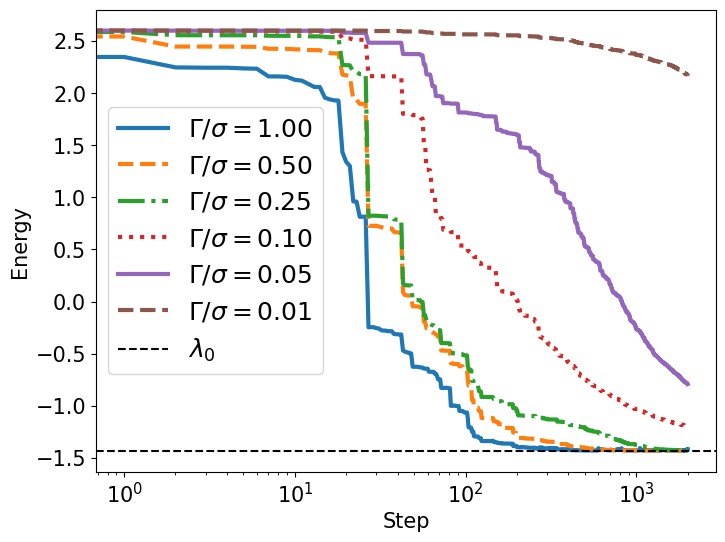

In [ ]:
plt.figure(figsize=(8,6))
linestyles = ["-", "--", "-.", ":", "-", "--"]
for idx in range(len(alpha_list)):
    ratio = alpha_list[idx] / np.sqrt(sigma)
    plt.plot(energy[0:Nstep+1,idx], linewidth=3, label=fr'$\Gamma/\sigma = {ratio:.2f}$', linestyle=linestyles[idx])

plt.axhline(y=ground_energy, color='k', linestyle='--', label=r'$\lambda_0$')
plt.xlabel(r'Step', fontsize=15)
plt.ylabel(r'Energy', fontsize=15)
plt.legend(fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale('log', base=10)
# plt.yscale('log', base=10)
plt.savefig("figures/ANNNI_energy.pdf", bbox_inches="tight", dpi=300)
plt.show()